# Probability

**Course Title:** ENM 3800: Learning from Data

**Instructor:** Eva Dyer

**Lecture:** 8 — Oct 6

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nerdslab/learningfromdata-course/blob/main/notebooks/Notebook_3/Notebook_3a_Probability.ipynb)

This notebook covers:

1. Probability and random variables
2. Expectation and variance
3. Common distributions and the *generating processes* that produce them
4. The Law of Large Numbers and the Central Limit Theorem

Big theme:

> Randomness has structure. A handful of distributions — each arising from a simple generating process — describe most of the data we meet, and averaging many independent draws leads inevitably to the Gaussian. That last fact, the Central Limit Theorem, is the bridge to statistics and inference in the notebooks that follow.

In [1]:
# Setup

import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

### Visualization Helpers

Run the setup cell below once. These helper functions make the later visualizations cleaner.


In [2]:
def clean_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    return ax


def show_widget_or_fallback(widget_fn, fallback_fn):
    """Try to show an ipywidgets interaction; otherwise run a static fallback."""
    try:
        import ipywidgets as widgets
        from IPython.display import display

        display(widget_fn(widgets))
    except Exception as e:
        print("Interactive widgets are not available in this environment.")
        print("Running a static example instead.")
        fallback_fn()
        print(e)

## Probability and Random Variables

### What is probability?

We will think of **probability** as a way to describe uncertainty about outcomes of a process.

- A *random experiment* is something we can conceptually repeat (coin flips, measuring height, etc.).
- The **sample space** is the set of all possible outcomes, usually denoted by $\Omega$. (coin flip: $\Omega = \{\text{heads}, \text{tails}\}$; person's height: $\Omega = \mathbb R^+$).

- A **probability distribution** assigns a probability $P(\omega)$ to each outcome $\omega \in \Omega$, or to ranges of outcomes in the continuous case. \
    A valid probability obeys **three rules**:
    1. **Non-negativity:** every event $A$ has $P(A) \ge 0$. Probabilities are never negative.
    2. **Normalization:** the whole sample space has probability one, $P(\Omega) = 1$. *Something* in $\Omega$ must happen.
    3. **Additivity:** if two events $A$ and $B$ are *mutually exclusive* (they cannot both occur, $A \cap B = \varnothing$), then
    $$
    P(A \cup B) = P(A) + P(B).
    $$
    A few consequences that follow directly from these rules:

    - $0 \le P(A) \le 1$ for any event.
    - $P(A^c) = 1 - P(A)$, with $A^c$ define as $A$ does *not* happen.


In data analysis, we rarely know the true distribution exactly, but we model it.



### Random variables

A **random variable** \(X\) is a function that maps outcomes to numbers:

$$
X: \Omega \rightarrow \mathbb{N} \;\text{(discrete)} \quad\text{or}\quad X: \Omega \rightarrow \mathbb{R} \;\text{(continuous)}
$$
more details

Examples:

- $X$ = number of heads in 10 coin flips.
- $X$ = height (in cm) of a randomly chosen person from a population.
- $X$ = daily temperature in Philadelphia.

We use random variables to connect uncertain processes to numerical data we can analyze.
Once we have a random variable, the natural question is: *how is its probability spread across the values it can take?*
That spread is called the **distribution** of $X$.
For a discrete random variable we describe it by listing the probability of each value, $P(X = x)$, the example below makes this concrete.

**Example (discrete).** Let $X$ be the result of rolling a fair six-sided die. The sample space is $\Omega = \{1, 2, 3, 4, 5, 6\}$, and the distribution assigns equal probability to each outcome:

$$
P(X = k) = \frac{1}{6}, \qquad k = 1, 2, \dots, 6.
$$

This is a **uniform distribution**: the probabilities are flat across all outcomes, and they sum to $1$ as the rules require. Listing $P(X=k)$ for every outcome *is* the distribution.




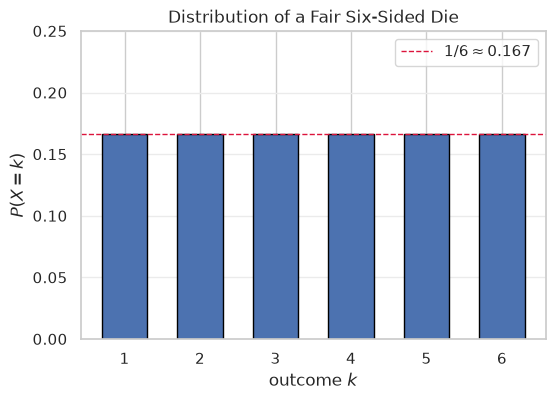

Probabilities: [0.167 0.167 0.167 0.167 0.167 0.167]
Sum of probabilities: 0.9999999999999999


In [3]:
#| code-fold: true
import matplotlib.pyplot as plt

# Fair six-sided die: each face k = 1..6 has probability 1/6
faces = np.arange(1, 7)
pmf = np.full(6, 1 / 6)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(faces, pmf, width=0.6, color="#4C72B0", edgecolor="black")
ax.set_xticks(faces)
ax.set_ylim(0, 0.25)
ax.set_xlabel("outcome $k$")
ax.set_ylabel("$P(X = k)$")
ax.set_title("Distribution of a Fair Six-Sided Die")
ax.axhline(
    1 / 6, color="crimson", linestyle="--", linewidth=1, label="$1/6 \\approx 0.167$"
)
ax.grid(True, axis="y", color="0.92")
ax.legend()
plt.show()

print("Probabilities:", np.round(pmf, 3))
print("Sum of probabilities:", pmf.sum())  # must equal 1

### Expectation and variance (intuitively)

- The **expected value** $\mathbb{E}[X]$ is the long-run average of $X$ over many repetitions.
- The **variance** $\mathrm{Var}(X)$ measures how spread out the values of \(X\) are around the mean.

Formally, for a discrete random variable:

$$
\mathbb{E}[X] = \sum_x x \, P(X = x), \quad
\mathrm{Var}(X) = \mathbb{E}[(X - \mathbb{E}[X])^2].
$$

In this course, we mostly use these ideas conceptually and estimate them from data. Every distribution we meet below comes with its own $\mathbb{E}[X]$ and $\mathrm{Var}(X)$, and a good sanity check is that the numbers we *simulate* land close to the formulas.


### Example: Coin flip simulation

Let's make the ideas above concrete with a random variable we can simulate.

Define $X$ = **the number of heads in 10 coin flips**. Each "experiment" is 10 flips of a fair coin, so $X$ takes values in $\{0, 1, \dots, 10\}$. By repeating the experiment many times, we can:

- see the **distribution** of $X$ (how often each number of heads occurs), and
- estimate its **expected value** $\mathbb{E}[X]$ from the data — the long-run average number of heads.

Since each flip is heads with probability $\tfrac{1}{2}$, we expect around $5$ heads on average. The simulation below lets us check that.



E[X] (mean) ≈ 4.996


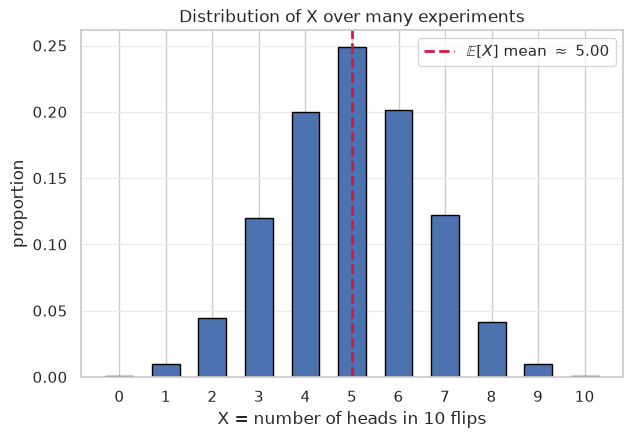

In [4]:
import matplotlib.pyplot as plt
import numpy as np

rng = np.random.default_rng(0)

# X = number of heads in 10 coin flips (one experiment).
# Repeat the experiment many times to see the distribution of X.
n_flips = 10
n_experiments = 10000

# 1 = heads, 0 = tails. Each row is one experiment of 10 flips;
# summing a row gives the number of heads in that experiment.
flips = rng.integers(0, 2, size=(n_experiments, n_flips))
X = flips.sum(axis=1)  # each value is in 0..10

# Estimate the mean from the data
sample_mean = X.mean()
print(f"E[X] (mean) ≈ {sample_mean:.3f}")

values = np.arange(0, n_flips + 1)
emp_pmf = np.array([np.mean(X == k) for k in values])

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(values, emp_pmf, width=0.6, color="#4C72B0", edgecolor="black")
ax.axvline(
    sample_mean,
    color="crimson",
    linestyle="--",
    linewidth=2,
    label=rf"$\mathbb{{E}}[X]$ mean $\approx$ {sample_mean:.2f}",
)
ax.set_xticks(values)
ax.set_xlabel("X = number of heads in 10 flips")
ax.set_ylabel("proportion")
ax.set_title("Distribution of X over many experiments")
ax.grid(True, axis="y", color="0.92")
ax.legend()
plt.show()

#### Quick Check

1. Where does the red mean line fall, and why is it close to 5?
2. Change `n_experiments` to a small number (e.g. 50) and rerun. Does the distribution look smooth, or bumpy? What happens when you set it back to 10,000?
3. Is the value of $X$ ever far from the mean (like 1 or 9 heads)? How often, compared to values near 5?



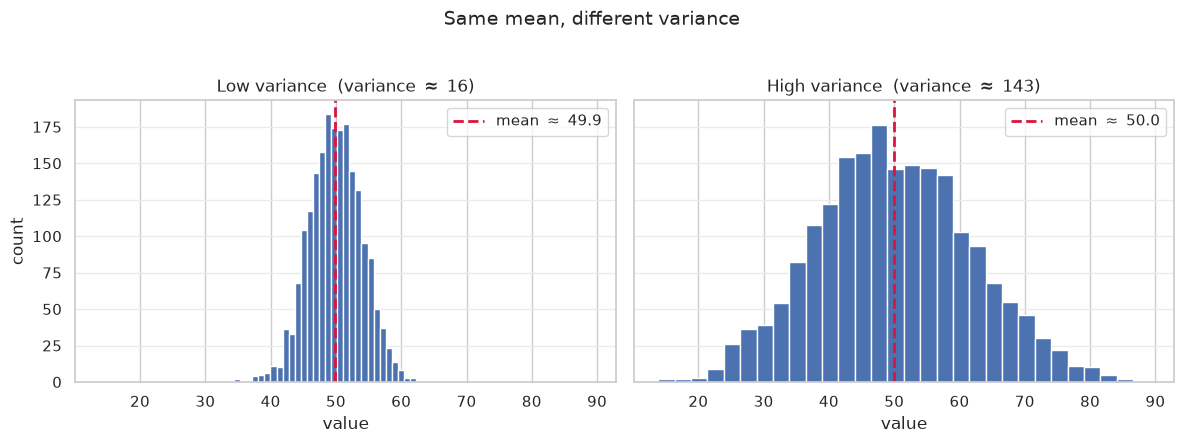

In [5]:
#| code-fold: true
import matplotlib.pyplot as plt
import numpy as np

rng = np.random.default_rng(0)

# Two made-up datasets with the SAME mean (50) but different spread.
low_var = rng.normal(loc=50, scale=4, size=2000)  # tightly clustered
high_var = rng.normal(loc=50, scale=12, size=2000)  # widely spread

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True, sharey=True)

for ax, data, name in zip(axes, [low_var, high_var], ["Low variance", "High variance"]):
    ax.hist(data, bins=30, color="#4C72B0", edgecolor="white")
    ax.axvline(
        data.mean(),
        color="crimson",
        linestyle="--",
        linewidth=2,
        label=f"mean $\\approx$ {data.mean():.1f}",
    )
    ax.set_title(f"{name}  (variance $\\approx$ {data.var():.0f})")
    ax.set_xlabel("value")
    ax.grid(True, axis="y", color="0.92")
    ax.legend()

axes[0].set_ylabel("count")
fig.suptitle("Same mean, different variance", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

#### Quick Check
1. Both plots are centered at the same place. If you were only told the **mean**, could you tell the two distributions apart? Why not?
2. Which one has the larger variance, and how can you see that from the shape of the histogram?
3. In your own words: what does **variance** measure that the **mean** does not?

The takeaway: the mean tells us *where* a distribution is centered, while the variance tells us *how spread out* it is. We usually need both to describe data.

## A Zoo of Distributions

You met a few distributions informally back in Module 1 (*Noise & Modeling Data*),
where we used them to picture variability. Here we make them precise.

A distribution is best understood not as a formula to memorize but as the
fingerprint of a **generating process** — a story about how the numbers come to
be. We have already met two:

- the **fair die**, where every face is equally likely (a *discrete uniform*), and
- the **number of heads in 10 flips**, a sum of coin flips (a *Binomial*).

Below we meet the rest of the everyday zoo. For each one, the pattern is the same:
describe the *process* that generates it, write down its $\mathbb{E}[X]$ and
$\mathrm{Var}(X)$, then **simulate the process** and check that the empirical
numbers match the theory.

### Bernoulli and Binomial: counting successes

The simplest random variable is a single **Bernoulli** trial: a yes/no event that
succeeds with probability $p$ (a coin flip, $p = 0.5$). It takes the value $1$
with probability $p$ and $0$ otherwise, so

$$
\mathbb{E}[X] = p, \qquad \mathrm{Var}(X) = p(1-p).
$$

Add up $n$ independent Bernoulli trials and you get a **Binomial** random variable
— exactly the "number of heads in $n$ flips" we simulated above. Its mean and
variance are just $n$ times the Bernoulli ones:

$$
\mathbb{E}[X] = np, \qquad \mathrm{Var}(X) = np(1-p).
$$

With $n = 10$ and $p = 0.5$ that predicts a mean of $5$ and a variance of $2.5$ —
check that against the coin-flip histogram you just ran.


### Continuous Uniform: every value equally likely

The continuous cousin of the fair die spreads probability **evenly across an
interval** $[a, b]$: no value in the range is preferred. It shows up whenever a
quantity is "equally likely to land anywhere" — rounding error, the fractional
part of an arrival time, a random point along a line. Its density is flat,
$f(x) = \tfrac{1}{b-a}$ on $[a, b]$, giving

$$
\mathbb{E}[X] = \frac{a + b}{2}, \qquad \mathrm{Var}(X) = \frac{(b-a)^2}{12}.
$$


In [6]:
# Generating process: draw values that are equally likely anywhere in [a, b].
rng = np.random.default_rng(1)
a, b = 2.0, 8.0
uniform_samples = rng.uniform(a, b, size=100_000)

print(f"mean      empirical {uniform_samples.mean():.3f}   theory {(a + b) / 2:.3f}")
print(f"variance  empirical {uniform_samples.var():.3f}   theory {(b - a) ** 2 / 12:.3f}")

mean      empirical 5.000   theory 5.000
variance  empirical 3.003   theory 3.000


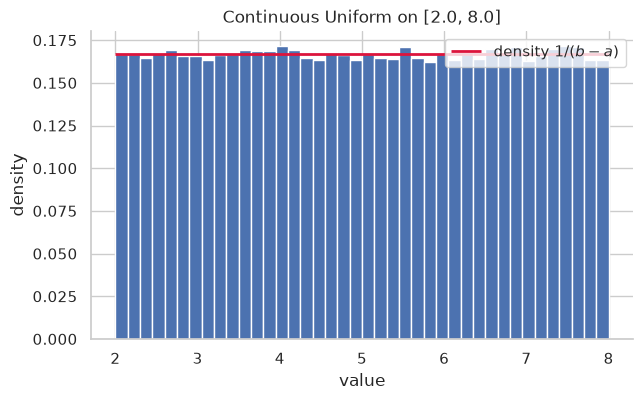

In [7]:
#| code-fold: true
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(uniform_samples, bins=40, density=True, color="#4C72B0", edgecolor="white")
ax.hlines(1 / (b - a), a, b, color="crimson", linewidth=2, label="density $1/(b-a)$")
ax.set_xlabel("value")
ax.set_ylabel("density")
ax.set_title(f"Continuous Uniform on [{a}, {b}]")
clean_axes(ax)
ax.legend()
plt.show()

### Poisson: counting rare events

Suppose events happen independently at a constant average rate — photons landing
on a detector, typos per page, customers arriving per minute. The **count** of
such events in a fixed window follows a **Poisson** distribution with rate
$\lambda$:

$$
P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}, \qquad
\mathbb{E}[X] = \lambda, \qquad \mathrm{Var}(X) = \lambda.
$$

(Mean and variance are *both* $\lambda$ — a Poisson signature.) The generating
process makes this vivid: chop the window into $n$ tiny slots, each of which
either gets an event (probability $p = \lambda/n$) or not. That is a
$\text{Binomial}(n, \lambda/n)$, and as $n \to \infty$ it *becomes* Poisson. So we
can generate Poisson counts two ways and confirm they agree.


In [8]:
# Two generating processes for the same distribution:
rng = np.random.default_rng(2)
lam = 3.0

# (a) directly: the count of events in one window
poisson_direct = rng.poisson(lam, size=100_000)

# (b) as the limit of many rare Bernoulli slots: n large, p = lam / n
n_slots = 2000
poisson_from_binom = rng.binomial(n_slots, lam / n_slots, size=100_000)

print(f"direct        mean {poisson_direct.mean():.3f}  var {poisson_direct.var():.3f}")
print(f"binomial→pois mean {poisson_from_binom.mean():.3f}  var {poisson_from_binom.var():.3f}")
print(f"theory        mean {lam:.3f}  var {lam:.3f}")

direct        mean 3.001  var 3.007
binomial→pois mean 3.003  var 2.991
theory        mean 3.000  var 3.000


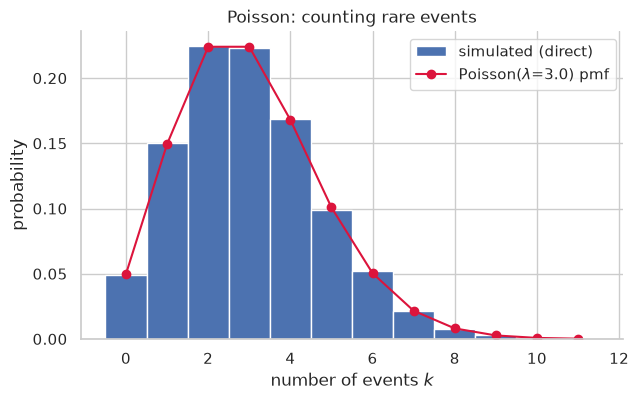

In [9]:
#| code-fold: true
k = np.arange(0, 12)
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(
    poisson_direct,
    bins=np.arange(-0.5, 12.5),
    density=True,
    color="#4C72B0",
    edgecolor="white",
    label="simulated (direct)",
)
ax.plot(k, stats.poisson.pmf(k, lam), "o-", color="crimson", label=f"Poisson($\\lambda$={lam}) pmf")
ax.set_xlabel("number of events $k$")
ax.set_ylabel("probability")
ax.set_title("Poisson: counting rare events")
clean_axes(ax)
ax.legend()
plt.show()

### Exponential: waiting for the next event

The Poisson counts *how many* events occur; the **Exponential** measures the
**waiting time between** them. If events arrive at rate $\lambda$, the gap until
the next one is Exponential with density $f(x) = \lambda e^{-\lambda x}$ for
$x \ge 0$, and

$$
\mathbb{E}[X] = \frac{1}{\lambda}, \qquad \mathrm{Var}(X) = \frac{1}{\lambda^2}.
$$

It is **memoryless**: having already waited a while tells you nothing about how
much longer you must wait. We can generate waiting times directly from uniform
random numbers by the *inverse-transform* trick, $x = -\ln(U)/\lambda$ — itself a
small window into how one generating process (uniform) can be reshaped into
another.


In [10]:
# Generating process: turn uniform draws into waiting times via -ln(U)/rate.
rng = np.random.default_rng(3)
rate = 0.5
u = rng.random(100_000)
wait_times = -np.log(u) / rate

print(f"mean      empirical {wait_times.mean():.3f}   theory 1/λ  {1 / rate:.3f}")
print(f"variance  empirical {wait_times.var():.3f}   theory 1/λ² {1 / rate**2:.3f}")

mean      empirical 2.009   theory 1/λ  2.000
variance  empirical 4.066   theory 1/λ² 4.000


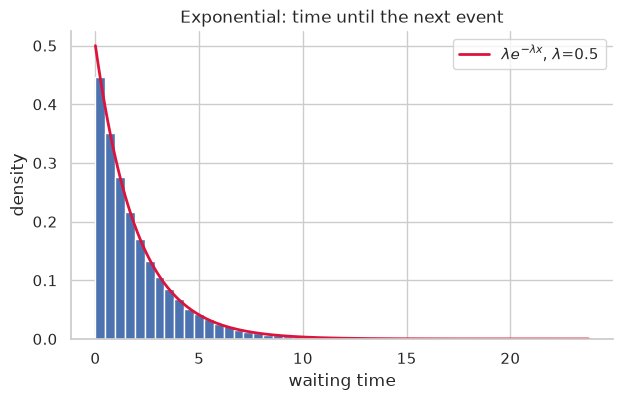

In [11]:
#| code-fold: true
grid = np.linspace(0, wait_times.max(), 200)
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(wait_times, bins=50, density=True, color="#4C72B0", edgecolor="white")
ax.plot(grid, rate * np.exp(-rate * grid), color="crimson", linewidth=2,
        label=f"$\\lambda e^{{-\\lambda x}}$, $\\lambda$={rate}")
ax.set_xlabel("waiting time")
ax.set_ylabel("density")
ax.set_title("Exponential: time until the next event")
clean_axes(ax)
ax.legend()
plt.show()

### Gaussian: the sum of many small effects

The **Gaussian** (or normal) distribution is the one we meet most often, and its
generating process explains why: whenever a quantity is the **sum of many small,
independent influences**, its distribution is approximately Gaussian. A person's
height is nudged by many genes and environmental factors; a measurement is jostled
by many tiny sources of error. The density is the familiar bell curve

$$
f(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\!\left(-\frac{(x - \mu)^2}{2\sigma^2}\right),
\qquad \mathbb{E}[X] = \mu, \qquad \mathrm{Var}(X) = \sigma^2.
$$

To *see* the process in action, build each value as the sum of many small uniform
"nudges." The result is bell-shaped even though no single nudge is — a preview of
the Central Limit Theorem we make precise at the end of this notebook.


In [12]:
# Generating process: each value is the sum of many small independent nudges.
rng = np.random.default_rng(4)
n_effects = 12
nudges = rng.uniform(-0.5, 0.5, size=(100_000, n_effects))
totals = nudges.sum(axis=1)

# Each nudge has mean 0 and variance 1/12, so the sum has mean 0, variance n/12.
print(f"mean      empirical {totals.mean():.3f}   theory {0.0:.3f}")
print(f"variance  empirical {totals.var():.3f}   theory n/12 = {n_effects / 12:.3f}")

mean      empirical 0.006   theory 0.000
variance  empirical 1.003   theory n/12 = 1.000


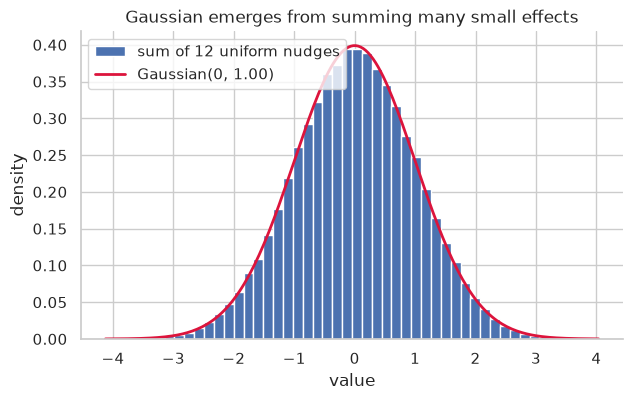

In [13]:
#| code-fold: true
grid = np.linspace(totals.min(), totals.max(), 200)
sigma = np.sqrt(n_effects / 12)
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(totals, bins=50, density=True, color="#4C72B0", edgecolor="white",
        label="sum of 12 uniform nudges")
ax.plot(grid, stats.norm.pdf(grid, 0, sigma), color="crimson", linewidth=2,
        label=f"Gaussian(0, {sigma**2:.2f})")
ax.set_xlabel("value")
ax.set_ylabel("density")
ax.set_title("Gaussian emerges from summing many small effects")
clean_axes(ax)
ax.legend()
plt.show()

### Summary: the everyday zoo

| Distribution | Generating process | $\mathbb{E}[X]$ | $\mathrm{Var}(X)$ |
|---|---|---|---|
| Bernoulli($p$) | one yes/no trial | $p$ | $p(1-p)$ |
| Binomial($n, p$) | number of successes in $n$ trials | $np$ | $np(1-p)$ |
| Discrete Uniform $\{1,\dots,k\}$ | equally likely faces | $\tfrac{k+1}{2}$ | $\tfrac{k^2 - 1}{12}$ |
| Continuous Uniform $[a, b]$ | equally likely anywhere in the interval | $\tfrac{a+b}{2}$ | $\tfrac{(b-a)^2}{12}$ |
| Poisson($\lambda$) | count of rare events per interval | $\lambda$ | $\lambda$ |
| Exponential($\lambda$) | waiting time until the next event | $\tfrac{1}{\lambda}$ | $\tfrac{1}{\lambda^2}$ |
| Gaussian($\mu, \sigma^2$) | sum of many small independent effects | $\mu$ | $\sigma^2$ |

Notice the family ties: a Binomial is a sum of Bernoullis; a Poisson is the limit
of a Binomial with many rare trials; an Exponential is the gap between Poisson
events; and a Gaussian is what you get by summing many small effects of *any*
shape. That last relationship is important enough to have a name.


#### Exercise: Name That Process

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nerdslab/learningfromdata-course/blob/main/notebooks/Notebook_3/Notebook_3a_Probability.ipynb#scrollTo=ex-generating-processes)

Each scenario below describes a *generating process*. For each one, name the
distribution it produces and write down its $\mathbb{E}[X]$ and $\mathrm{Var}(X)$
from the summary table.

1. A call center receives, on average, 4 calls per minute, independently. $X$ = the
   number of calls in a given minute.
2. A bus is equally likely to arrive at any moment in the 10 minutes after you
   reach the stop. $X$ = how long you wait.
3. $X$ = the time between two successive calls at the center in scenario 1.
4. A quiz has 20 true/false questions and a student guesses each one. $X$ = the
   number answered correctly by chance.

Then **verify one of your answers by simulation.** In the cell below, generate
many samples *from the process itself* (not from a formula for the answer), and
check that the empirical mean and variance match the theoretical values you wrote
down. Scenario 3 is a good choice: generate call times, take the gaps between
them, and compare to $\mathbb{E}[X] = 1/\lambda$ and $\mathrm{Var}(X) = 1/\lambda^2$.


In [14]:
# Your simulation here. A starting point for scenario 3 (rate = 4 calls/min):
rng = np.random.default_rng(7)
rate = 4.0
# Hint: waiting times between events are Exponential; simulate them directly with
# rng.exponential(scale=1 / rate, size=...), then compare .mean() and .var()
# against 1 / rate and 1 / rate**2.

## The Law of Large Numbers and the Central Limit Theorem

We have been estimating expectations by simulating and averaging. Two theorems
justify that habit and connect probability to the statistics that follow.

### The Law of Large Numbers (LLN)

> As the sample size grows, the **sample mean** $\bar{x}_n$ converges to the true
> expected value $\mathbb{E}[X]$.

This is why simulation works at all, and why larger samples give more trustworthy
estimates. Below we draw from a very skewed distribution — the Exponential — and
watch the running average settle onto its true mean $1/\lambda$.


In [15]:
# Running average of Exponential draws should converge to the true mean 1/rate.
rng = np.random.default_rng(5)
rate = 0.5
true_mean = 1 / rate
draws = rng.exponential(scale=1 / rate, size=5000)  # numpy parameterizes by scale = 1/λ
running_avg = np.cumsum(draws) / np.arange(1, len(draws) + 1)

print(f"true mean 1/λ = {true_mean:.3f}")
print(f"running average after {len(draws)} draws = {running_avg[-1]:.3f}")

true mean 1/λ = 2.000
running average after 5000 draws = 1.954


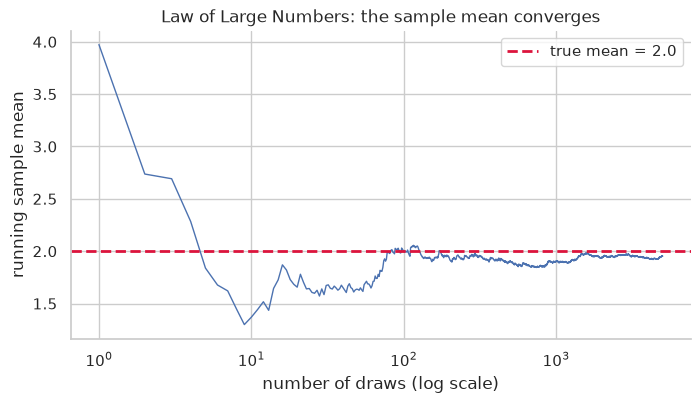

In [16]:
#| code-fold: true
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.arange(1, len(draws) + 1), running_avg, color="#4C72B0", linewidth=1)
ax.axhline(true_mean, color="crimson", linestyle="--", linewidth=2,
           label=f"true mean = {true_mean:.1f}")
ax.set_xscale("log")
ax.set_xlabel("number of draws (log scale)")
ax.set_ylabel("running sample mean")
ax.set_title("Law of Large Numbers: the sample mean converges")
clean_axes(ax)
ax.legend()
plt.show()

### The Central Limit Theorem (CLT)

The LLN says the sample mean converges to a *number*. The **Central Limit
Theorem** says something stronger and more surprising — it tells us the *shape* of
the sample mean's uncertainty:

> For large $n$, the sample mean $\bar{x}$ is approximately **Gaussian**, with mean
> $\mu$ and standard deviation $\sigma / \sqrt{n}$ — *no matter what distribution
> the individual data came from.*

To feel how strong this is, we start from the Exponential again — a distribution
that looks nothing like a bell curve. We repeatedly draw a sample of size $n$,
compute its mean, and look at the distribution of those means. As $n$ grows, the
skew washes out and a Gaussian emerges.


In [17]:
# Sampling distribution of the mean, starting from a skewed Exponential population.
rng = np.random.default_rng(6)
rate = 0.5
pop_mean = 1 / rate           # Exponential mean = 1/λ
pop_sd = 1 / rate             # Exponential sd  = 1/λ


def sample_means(sample_size, n_samples=3000):
    draws = rng.exponential(scale=1 / rate, size=(n_samples, sample_size))
    return draws.mean(axis=1)


sizes = [2, 10, 50]
means_by_size = {n: sample_means(n) for n in sizes}
for n in sizes:
    predicted_se = pop_sd / np.sqrt(n)
    print(f"n={n:>3}:  observed SE {means_by_size[n].std():.3f}   CLT σ/√n {predicted_se:.3f}")

n=  2:  observed SE 1.370   CLT σ/√n 1.414
n= 10:  observed SE 0.646   CLT σ/√n 0.632
n= 50:  observed SE 0.279   CLT σ/√n 0.283


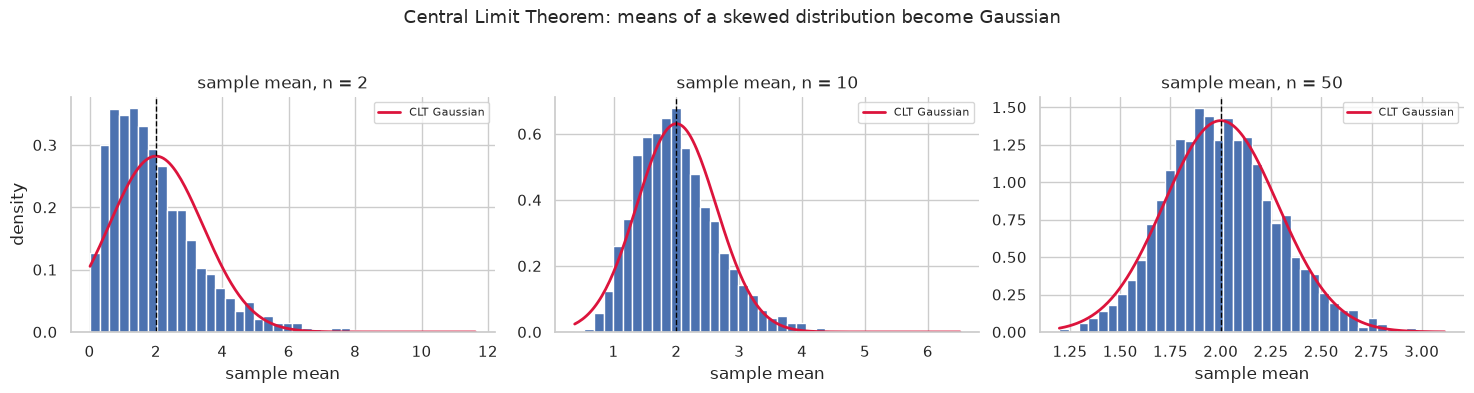

In [18]:
#| code-fold: true
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, n in zip(axes, sizes):
    data = means_by_size[n]
    ax.hist(data, bins=40, density=True, color="#4C72B0", edgecolor="white")
    grid = np.linspace(data.min(), data.max(), 200)
    ax.plot(grid, stats.norm.pdf(grid, pop_mean, pop_sd / np.sqrt(n)),
            color="crimson", linewidth=2, label="CLT Gaussian")
    ax.axvline(pop_mean, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"sample mean, n = {n}")
    ax.set_xlabel("sample mean")
    clean_axes(ax)
    ax.legend(fontsize=8)
axes[0].set_ylabel("density")
fig.suptitle("Central Limit Theorem: means of a skewed distribution become Gaussian", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### The standard error shrinks with $\sqrt{n}$

The CLT gives the spread of the sample mean an exact form — the **standard error**

$$
SE = \frac{\sigma}{\sqrt{n}}.
$$

Uncertainty decreases with sample size, but only as $\sqrt{n}$: to cut the standard
error in half you need about **four times** as much data. This single curve is why
larger studies give tighter estimates, and it is the quantity every confidence
interval and t-test in the next notebook is built on.


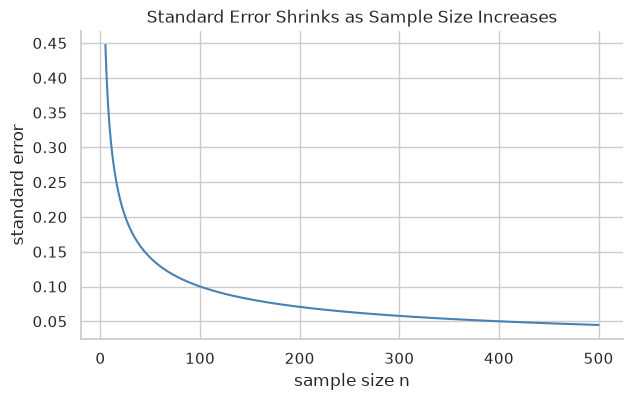

In [19]:
#| code-fold: true
n_values = np.arange(5, 501)
sigma = 1
standard_errors = sigma / np.sqrt(n_values)

plt.figure(figsize=(7, 4))
plt.plot(n_values, standard_errors, color="steelblue")
plt.xlabel("sample size n")
plt.ylabel("standard error")
plt.title("Standard Error Shrinks as Sample Size Increases")
clean_axes(plt.gca())
plt.show()

### Where this leads

The CLT is the bridge from probability to **inference**. Because the sample mean is
approximately Gaussian with a *known* spread $\sigma/\sqrt{n}$, we can attach
uncertainty to an estimate (a **confidence interval**) and ask whether an observed
difference is larger than sampling noise would explain (a **hypothesis test**).
Those are exactly the tools of the next notebook, **Statistics 1**.
